# Normal mixture – 6 model variants

This notebook duplicates the same workflow **six times** (models 1–6). Edit each `mix_model_i` / preprocessing block and re-run that model’s cells to compare outputs. The **map comparison is only at the end**.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering

## Label assignment & PSM
We compute a posterior similarity matrix (PSM) from the sampled latent labels `z`, sort it with hierarchical clustering for visualization, then choose an “optimal” partition via Binder loss over a range of cluster counts.

In [2]:
## For each draw:
# - compare couples of observations
# - if they are equal (same label) increment the counter
# - normalize

# At the end psm[i, j] is the posterior probability that observations i and j belong to the same cluster

# Shape is n_draws x n_obs, and the numbers are class labels

@njit
def build_psm(posterior):
    n_draws, n_obs = posterior.shape
    psm = np.zeros((n_obs, n_obs))
    for row in posterior:
        for r_idx, i in enumerate(row):
            for c_idx, j in enumerate(row):
                if i == j:
                    psm[r_idx, c_idx] += 1
                    
    psm /= n_draws
        
    return psm

In [17]:
def order_by_hclust(psm, method="average"):
    psm = np.asarray(psm)
    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)   # NxN -> condensed
    Z = linkage(condensed, method=method)
    return leaves_list(Z) 

In [4]:
def binder_loss(psm, labels):
    # expected Binder loss from PSM (sum over i<j)
    labels = np.asarray(labels)
    A = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(psm.shape[0], k=1)
    return float(np.sum(np.abs(A[iu] - psm[iu])))

def binder_optimal_partition(psm, k_min, k_max):
    psm = np.asarray(psm, dtype=float)
    psm = 0.5 * (psm + psm.T)
    np.fill_diagonal(psm, 1.0)

    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)

    best_loss = np.inf
    best_labels = None

    for k in range(k_min, min(k_max, psm.shape[0]) + 1):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
            metric="precomputed",  
        )
        labels = model.fit_predict(dist)
        loss = binder_loss(psm, labels)
        if loss < best_loss:
            best_loss = loss
            best_labels = labels

    return best_labels, best_loss

In [5]:
df = gpd.read_file('../data/updated_data.geojson')

df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

## Model 1
- NO cluster specific Beta
- NO spatial effect
- NO cluster specific sigma
- offset
- cluster specific alpha

In [6]:
df_1 = pd.read_csv('../data/updated_data.csv')

In [7]:
y_1 = df_1["fem_empl_rate"].to_numpy()
y_1 = y_1 / 100
y_star_1 = np.log(y_1 / (1 - y_1))

selected_covariates_1 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_1 = df_1[selected_covariates_1].to_numpy()
X_scaler_1 = StandardScaler()
X_star_1 = X_scaler_1.fit_transform(X_1)

offset_1 = df_1["wr_men"].to_numpy()
offset_1 = offset_1 / 100
offset_star_1 = np.log(offset_1 / (1 - offset_1))

N_1 = 107 
P_1 = len(selected_covariates_1) 
K_1 = 3 

In [8]:
mix_model_1 = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 
  sigma ~ normal(0, 1);

  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [9]:
with open("normal_mixture_1.stan", "w") as f:
    f.write(mix_model_1)

In [10]:
data_1 = {
    "N": int(N_1),
    "P": int(P_1),
    "K": int(K_1),
    "y_star": y_star_1.astype(float),
    "X_star": X_star_1.astype(float),
    "offset_star": offset_star_1.astype(float),
}

In [11]:
mix_stan_1 = CmdStanModel(stan_file="normal_mixture_1.stan")

18:13:30 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_1.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_1.exe
18:15:00 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_1.exe


In [12]:
fit_1 = mix_stan_1.sample(
    data=data_1,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:15:01 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:15:31 - cmdstanpy - INFO - CmdStan done processing.


In [13]:
fit_1.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [14]:
z_draws_1 = fit_1.stan_variable("z")   # shape: (n_draws, N)

In [15]:
psm_1 = build_psm(z_draws_1.astype(np.int64))

In [18]:
order_1 = order_by_hclust(psm_1)
psm_sorted_1 = psm_1[np.ix_(order_1, order_1)]

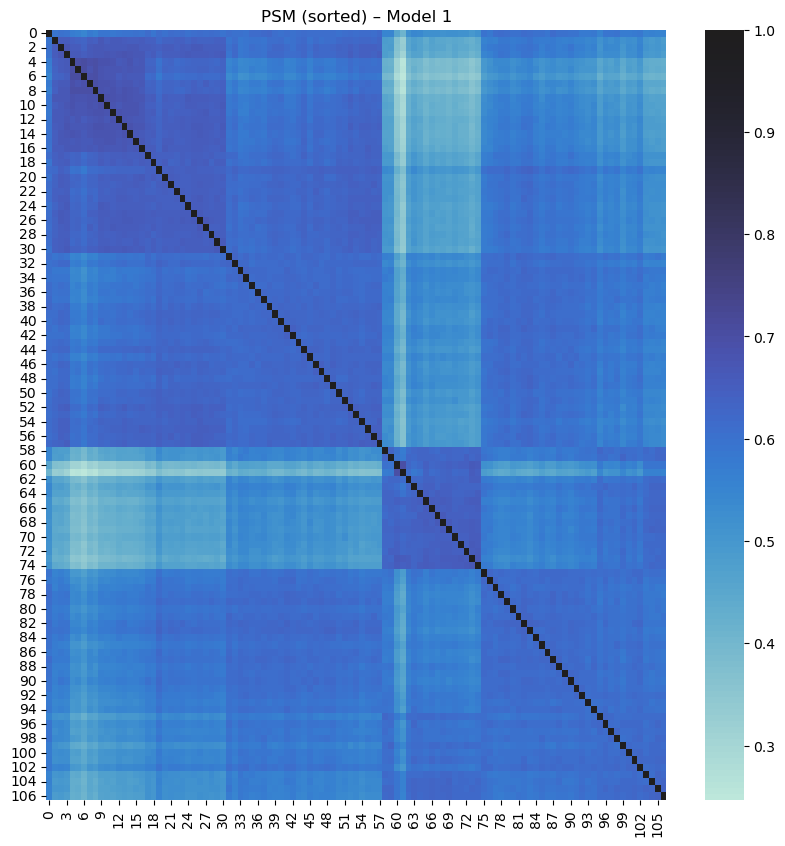

In [19]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_1, center=1)
plt.title("PSM (sorted) – Model 1")
plt.show()

In [20]:
labels_opt_1, loss_opt_1 = binder_optimal_partition(psm_1, k_min=1, k_max=5)
loss_opt_1

2410.5885

In [21]:
labels_opt_1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [22]:
labels_1 = labels_opt_1 + 1
labels_1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model 2
- NO cluster specific Beta
- NO spatial effect
- NO cluster specific sigma
- NO offset
- cluster specific alpha

In [23]:
df_2 = pd.read_csv('../data/updated_data.csv')

In [24]:
y_2 = df_2["fem_empl_rate"].to_numpy()
y_2 = y_2 / 100
y_star_2 = np.log(y_2 / (1 - y_2))

selected_covariates_2 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_2 = df_2[selected_covariates_2].to_numpy()
X_scaler_2 = StandardScaler()
X_star_2 = X_scaler_2.fit_transform(X_2)

offset_2 = df_2["wr_men"].to_numpy()
offset_2 = offset_2 / 100
offset_star_2 = np.log(offset_2 / (1 - offset_2))

N_2 = 107 
P_2 = len(selected_covariates_2) 
K_2 = 3 

In [25]:
mix_model_2 = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;                  
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 
  sigma ~ normal(0, 1);

  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta);
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta;
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [26]:
with open("normal_mixture_2.stan", "w") as f:
    f.write(mix_model_2)

In [27]:
data_2 = {
    "N": int(N_2),
    "P": int(P_2),
    "K": int(K_2),
    "y_star": y_star_2.astype(float),
    "X_star": X_star_2.astype(float),
}

In [28]:
mix_stan_2 = CmdStanModel(stan_file="normal_mixture_2.stan")

18:18:29 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_2.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_2.exe
18:19:58 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_2.exe


In [29]:
fit_2 = mix_stan_2.sample(
    data=data_2,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:19:59 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:20:26 - cmdstanpy - INFO - CmdStan done processing.


In [30]:
fit_2.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [31]:
z_draws_2 = fit_2.stan_variable("z")   # shape: (n_draws, N)

In [32]:
psm_2 = build_psm(z_draws_2.astype(np.int64))

In [33]:
order_2 = order_by_hclust(psm_2)
psm_sorted_2 = psm_2[np.ix_(order_2, order_2)]

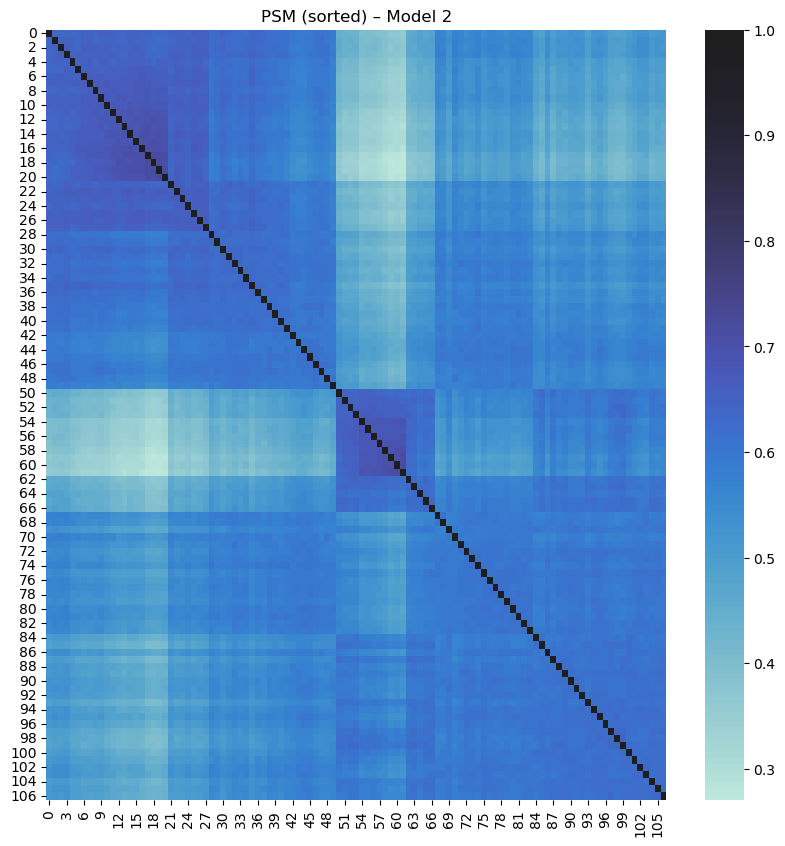

In [34]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_2, center=1)
plt.title("PSM (sorted) – Model 2")
plt.show()

In [35]:
labels_opt_2, loss_opt_2 = binder_optimal_partition(psm_2, k_min=1, k_max=5)
loss_opt_2

2539.4546250000003

In [36]:
labels_opt_2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
labels_2 = labels_opt_2 + 1
labels_2

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model 3
- NO cluster specific Beta
- spatial effect
- NO cluster specific sigma
- offset
- cluster specific alpha

In [38]:
df_3 = pd.read_csv('../data/updated_data.csv')

In [39]:
y_3 = df_3["fem_empl_rate"].to_numpy()
y_3 = y_3 / 100
y_star_3 = np.log(y_3 / (1 - y_3))

selected_covariates_3 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_3 = df_3[selected_covariates_3].to_numpy()
X_scaler_3 = StandardScaler()
X_star_3 = X_scaler_3.fit_transform(X_3)

offset_3 = df_3["wr_men"].to_numpy()
offset_3 = offset_3 / 100
offset_star_3 = np.log(offset_3 / (1 - offset_3))

N_3 = 107 
P_3 = len(selected_covariates_3) 
K_3 = 3 

In [44]:
mix_model_3 = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star; 
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi_raw;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw);
}


model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 
  sigma ~ normal(0, 1);

  tau2  ~ gamma(1, 1);
  rho   ~ beta(2,2);

  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  phi_raw ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + offset_star[i] + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + offset_star[i] + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [45]:
with open("normal_mixture_3.stan", "w") as f:
    f.write(mix_model_3)

In [46]:
data_3 = {
    "N": int(N_3),
    "P": int(P_3),
    "K": int(K_3),
    "y_star": y_star_3.astype(float),
    "X_star": X_star_3.astype(float),
    "offset_star": offset_star_3.astype(float),
    "W": W,
}

In [47]:
mix_stan_3 = CmdStanModel(stan_file="normal_mixture_3.stan")

18:23:49 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_3.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_3.exe
18:25:27 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_3.exe


In [48]:
fit_3 = mix_stan_3.sample(
    data=data_3,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:25:29 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:30:27 - cmdstanpy - INFO - CmdStan done processing.
18:30:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'normal_mixture_3.stan', line 75, column 2 to column 22)
Consider re-running with show_console=True if the above output is unclear!


18:30:27 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 17 divergent transitions (0.9%)
	Chain 1 had 113 iterations at max treedepth (5.7%)
	Chain 2 had 469 divergent transitions (23.4%)
	Chain 3 had 104 divergent transitions (5.2%)
	Chain 4 had 148 divergent transitions (7.4%)
	Chain 4 had 2 iterations at max treedepth (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [49]:
fit_3.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'tau2', 'phi_raw', 'rho', 'phi', 'z'])

In [50]:
z_draws_3 = fit_3.stan_variable("z")   # shape: (n_draws, N)

In [51]:
psm_3 = build_psm(z_draws_3.astype(np.int64))

In [52]:
order_3 = order_by_hclust(psm_3)
psm_sorted_3 = psm_3[np.ix_(order_3, order_3)]

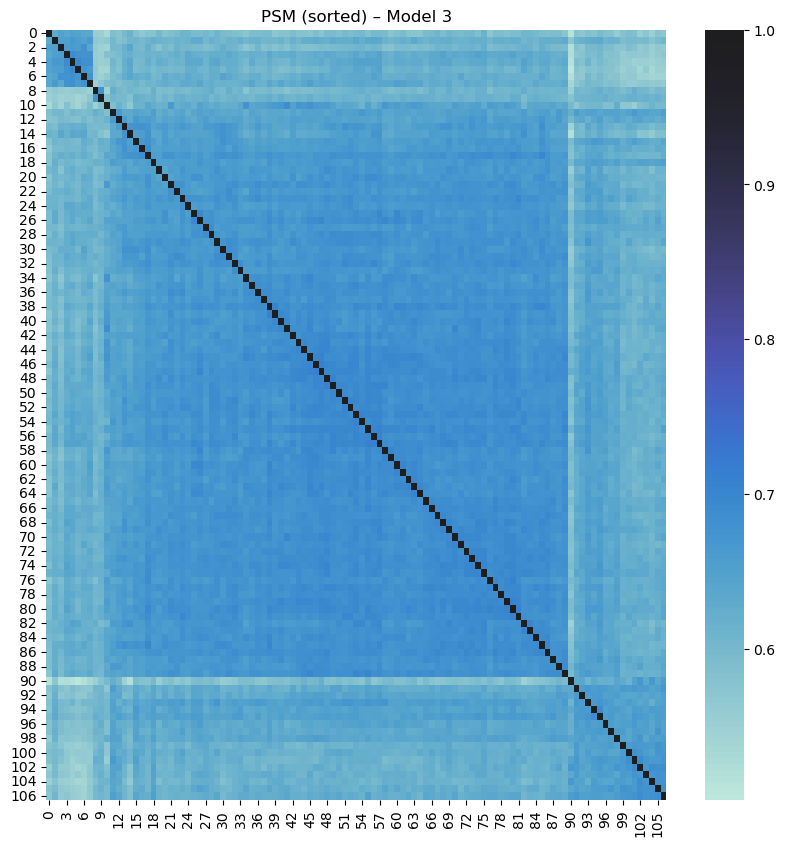

In [53]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_3, center=1)
plt.title("PSM (sorted) – Model 3")
plt.show()

In [54]:
labels_opt_3, loss_opt_3 = binder_optimal_partition(psm_3, k_min=1, k_max=5)
loss_opt_3

1984.961875

In [55]:
labels_opt_3

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [56]:
labels_3 = labels_opt_3 + 1
labels_3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model 4
- NO cluster specific Beta
- spatial effect
- NO cluster specific sigma
- NO offset
- cluster specific alpha

In [57]:
df_4 = pd.read_csv('../data/updated_data.csv')

In [58]:
y_4 = df_4["fem_empl_rate"].to_numpy()
y_4 = y_4 / 100
y_star_4 = np.log(y_4 / (1 - y_4))

selected_covariates_4 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_4 = df_4[selected_covariates_4].to_numpy()
X_scaler_4 = StandardScaler()
X_star_4 = X_scaler_4.fit_transform(X_4)

offset_4 = df_4["wr_men"].to_numpy()
offset_4 = offset_4 / 100
offset_star_4 = np.log(offset_4 / (1 - offset_4))

N_4 = 107 
P_4 = len(selected_covariates_4) 
K_4 = 3 

In [63]:
mix_model_4 = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
  real<lower=0> tau2;                  // CAR precision
  vector[N] phi_raw;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw);
}


model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 
  sigma ~ normal(0, 1);

  tau2  ~ gamma(1, 1);
  rho   ~ beta(2,2);

  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  phi_raw ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [64]:
with open("normal_mixture_4.stan", "w") as f:
    f.write(mix_model_4)

In [65]:
data_4 = {
    "N": int(N_4),
    "P": int(P_4),
    "K": int(K_4),
    "y_star": y_star_4.astype(float),
    "X_star": X_star_4.astype(float),
    "W": W,
}

In [66]:
mix_stan_4 = CmdStanModel(stan_file="normal_mixture_4.stan")

18:33:05 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_4.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_4.exe
18:34:42 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_4.exe


In [67]:
fit_4 = mix_stan_4.sample(
    data=data_4,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:34:42 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:40:26 - cmdstanpy - INFO - CmdStan done processing.
18:40:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'normal_mixture_4.stan', line 74, column 2 to column 22)
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in 'normal_mixture_4.stan', line 74, column 2 to column 22)
Consider re-running with show_console=True if the above output is unclear!


18:40:26 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 164 divergent transitions (8.2%)
	Chain 1 had 2 iterations at max treedepth (0.1%)
	Chain 2 had 39 divergent transitions (1.9%)
	Chain 2 had 25 iterations at max treedepth (1.2%)
	Chain 3 had 1 divergent transitions (0.1%)
	Chain 3 had 314 iterations at max treedepth (15.7%)
	Chain 4 had 68 divergent transitions (3.4%)
	Chain 4 had 12 iterations at max treedepth (0.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [68]:
fit_4.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'tau2', 'phi_raw', 'rho', 'phi', 'z'])

In [69]:
z_draws_4 = fit_4.stan_variable("z")   # shape: (n_draws, N)

In [70]:
psm_4 = build_psm(z_draws_4.astype(np.int64))

In [71]:
order_4 = order_by_hclust(psm_4)
psm_sorted_4 = psm_4[np.ix_(order_4, order_4)]

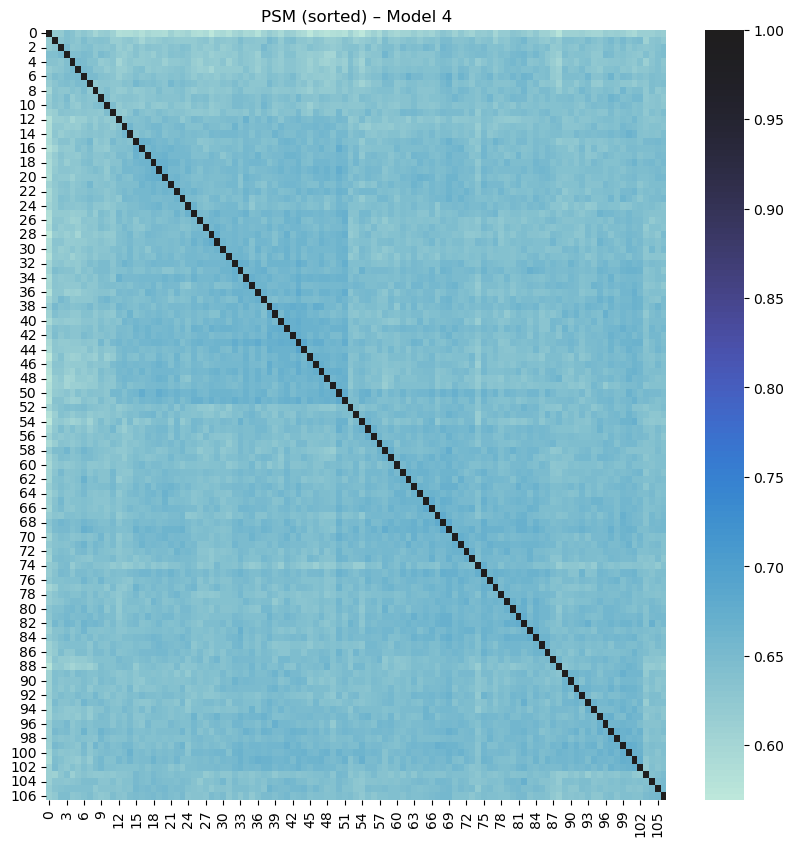

In [72]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_4, center=1)
plt.title("PSM (sorted) – Model 4")
plt.show()

In [73]:
labels_opt_4, loss_opt_4 = binder_optimal_partition(psm_4, k_min=1, k_max=5)
loss_opt_4

2017.254375

In [74]:
labels_opt_4

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [75]:
labels_4 = labels_opt_4 + 1
labels_4

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model 5
- NO cluster specific Beta
- NO spatial effect
- cluster specific sigma
- offset
- cluster specific alpha

In [76]:
df_5 = pd.read_csv('../data/updated_data.csv')

In [77]:
y_5 = df_5["fem_empl_rate"].to_numpy()
y_5 = y_5 / 100
y_star_5 = np.log(y_5 / (1 - y_5))

selected_covariates_5 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_5 = df_5[selected_covariates_5].to_numpy()
X_scaler_5 = StandardScaler()
X_star_5 = X_scaler_5.fit_transform(X_5)

offset_5 = df_5["wr_men"].to_numpy()
offset_5 = offset_5 / 100
offset_star_5 = np.log(offset_5 / (1 - offset_5))

N_5 = 107 
P_5 = len(selected_covariates_5) 
K_5 = 3 

In [78]:
mix_model_5 = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  vector<lower=1e-6>[K] sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 

  for (k in 1:K) {
    sigma[k] ~ normal(0, 1);
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma[k]);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma[k]);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [79]:
with open("normal_mixture_5.stan", "w") as f:
    f.write(mix_model_5)

In [80]:
data_5 = {
    "N": int(N_5),
    "P": int(P_5),
    "K": int(K_5),
    "y_star": y_star_5.astype(float),
    "X_star": X_star_5.astype(float),
    "offset_star": offset_star_5.astype(float),
}

In [81]:
mix_stan_5 = CmdStanModel(stan_file="normal_mixture_5.stan")

18:40:28 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_5.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_5.exe
18:41:53 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_5.exe


In [82]:
fit_5 = mix_stan_5.sample(
    data=data_5,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:41:54 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:43:09 - cmdstanpy - INFO - CmdStan done processing.
18:43:09 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 2 had 2 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [83]:
fit_5.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [84]:
z_draws_5 = fit_5.stan_variable("z")   # shape: (n_draws, N)

In [85]:
psm_5 = build_psm(z_draws_5.astype(np.int64))

In [86]:
order_5 = order_by_hclust(psm_5)
psm_sorted_5 = psm_5[np.ix_(order_5, order_5)]

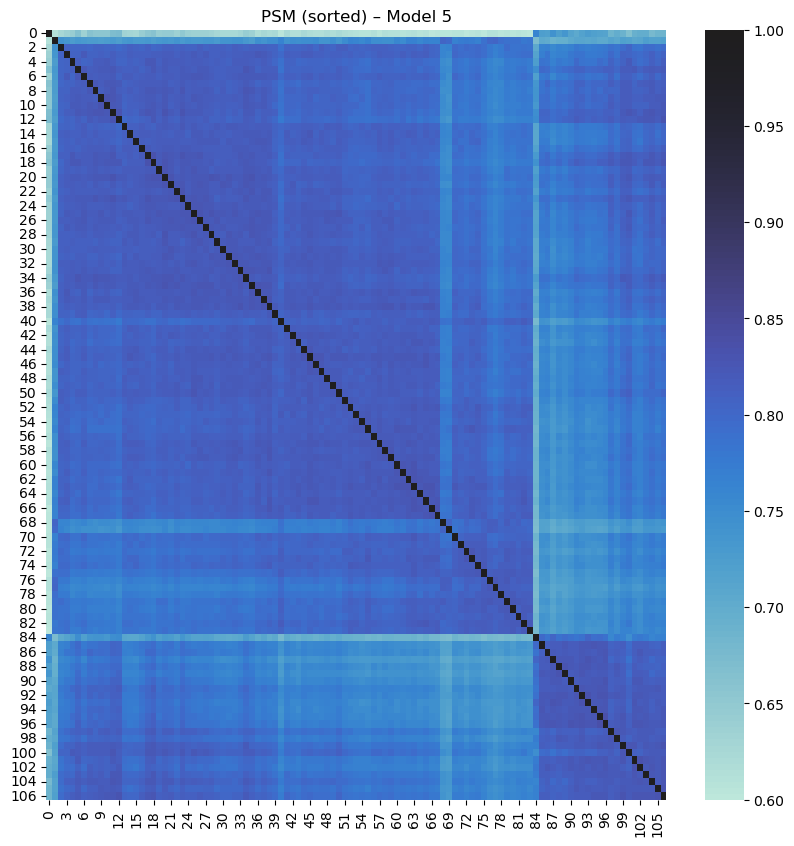

In [87]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_5, center=1)
plt.title("PSM (sorted) – Model 5")
plt.show()

In [88]:
labels_opt_5, loss_opt_5 = binder_optimal_partition(psm_5, k_min=1, k_max=5)
loss_opt_5

1192.0038749999999

In [89]:
labels_opt_5

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [90]:
labels_5 = labels_opt_5 + 1
labels_5

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Model 6
- NO cluster specific Beta
- NO spatial effect
- cluster specific sigma
- NO offset
- cluster specific alpha

In [91]:
df_6 = pd.read_csv('../data/updated_data.csv')

In [92]:
y_6 = df_6["fem_empl_rate"].to_numpy()
y_6 = y_6 / 100
y_star_6 = np.log(y_6 / (1 - y_6))

selected_covariates_6 = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X_6 = df_6[selected_covariates_6].to_numpy()
X_scaler_6 = StandardScaler()
X_star_6 = X_scaler_6.fit_transform(X_6)

offset_6 = df_6["wr_men"].to_numpy()
offset_6 = offset_6 / 100
offset_star_6 = np.log(offset_6 / (1 - offset_6))

N_6 = 107 
P_6 = len(selected_covariates_6) 
K_6 = 3 

In [98]:
mix_model_6 = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;                  
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  vector<lower=1e-6>[K] sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 

  for (k in 1:K) {
    sigma[k] ~ normal(0, 1);
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta);
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma[k]);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta;
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma[k]);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [99]:
with open("normal_mixture_6.stan", "w") as f:
    f.write(mix_model_6)

In [100]:
data_6 = {
    "N": int(N_6),
    "P": int(P_6),
    "K": int(K_6),
    "y_star": y_star_6.astype(float),
    "X_star": X_star_6.astype(float),
}

In [101]:
mix_stan_6 = CmdStanModel(stan_file="normal_mixture_6.stan")

18:46:01 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_6.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_6.exe
18:47:28 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture_6.exe


In [102]:
fit_6 = mix_stan_6.sample(
    data=data_6,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

18:47:28 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

18:49:43 - cmdstanpy - INFO - CmdStan done processing.
18:49:43 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


In [103]:
fit_6.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [104]:
z_draws_6 = fit_6.stan_variable("z")   # shape: (n_draws, N)

In [105]:
psm_6 = build_psm(z_draws_6.astype(np.int64))

In [106]:
order_6 = order_by_hclust(psm_6)
psm_sorted_6 = psm_6[np.ix_(order_6, order_6)]

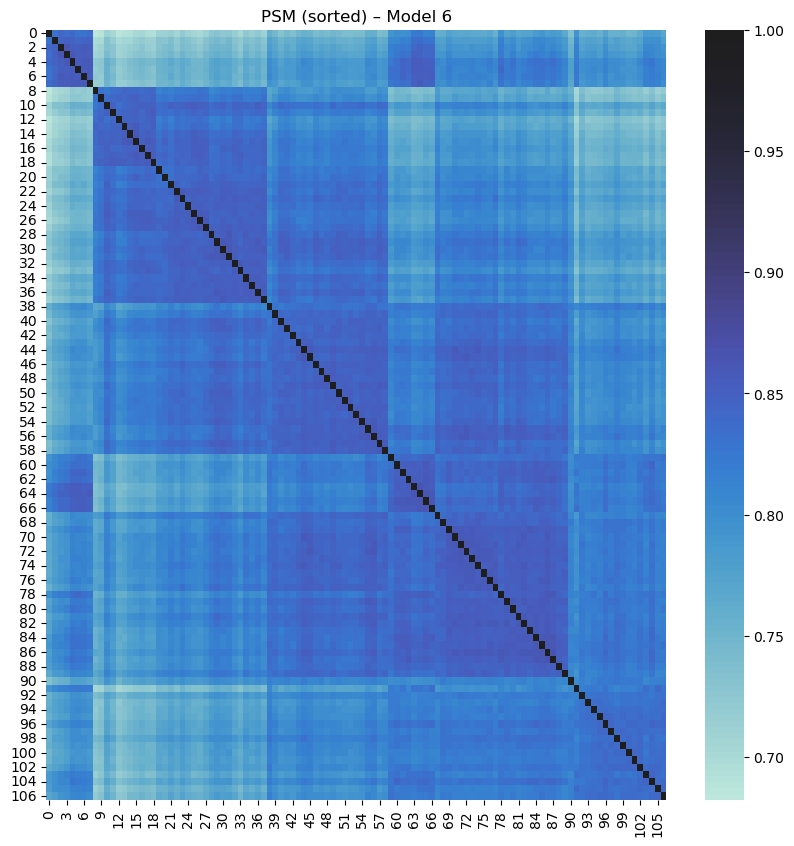

In [107]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted_6, center=1)
plt.title("PSM (sorted) – Model 6")
plt.show()

In [108]:
labels_opt_6, loss_opt_6 = binder_optimal_partition(psm_6, k_min=1, k_max=5)
loss_opt_6

1067.34625

In [109]:
labels_opt_6

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [110]:
labels_6 = labels_opt_6 + 1
labels_6

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## Map comparison (all 6 models)

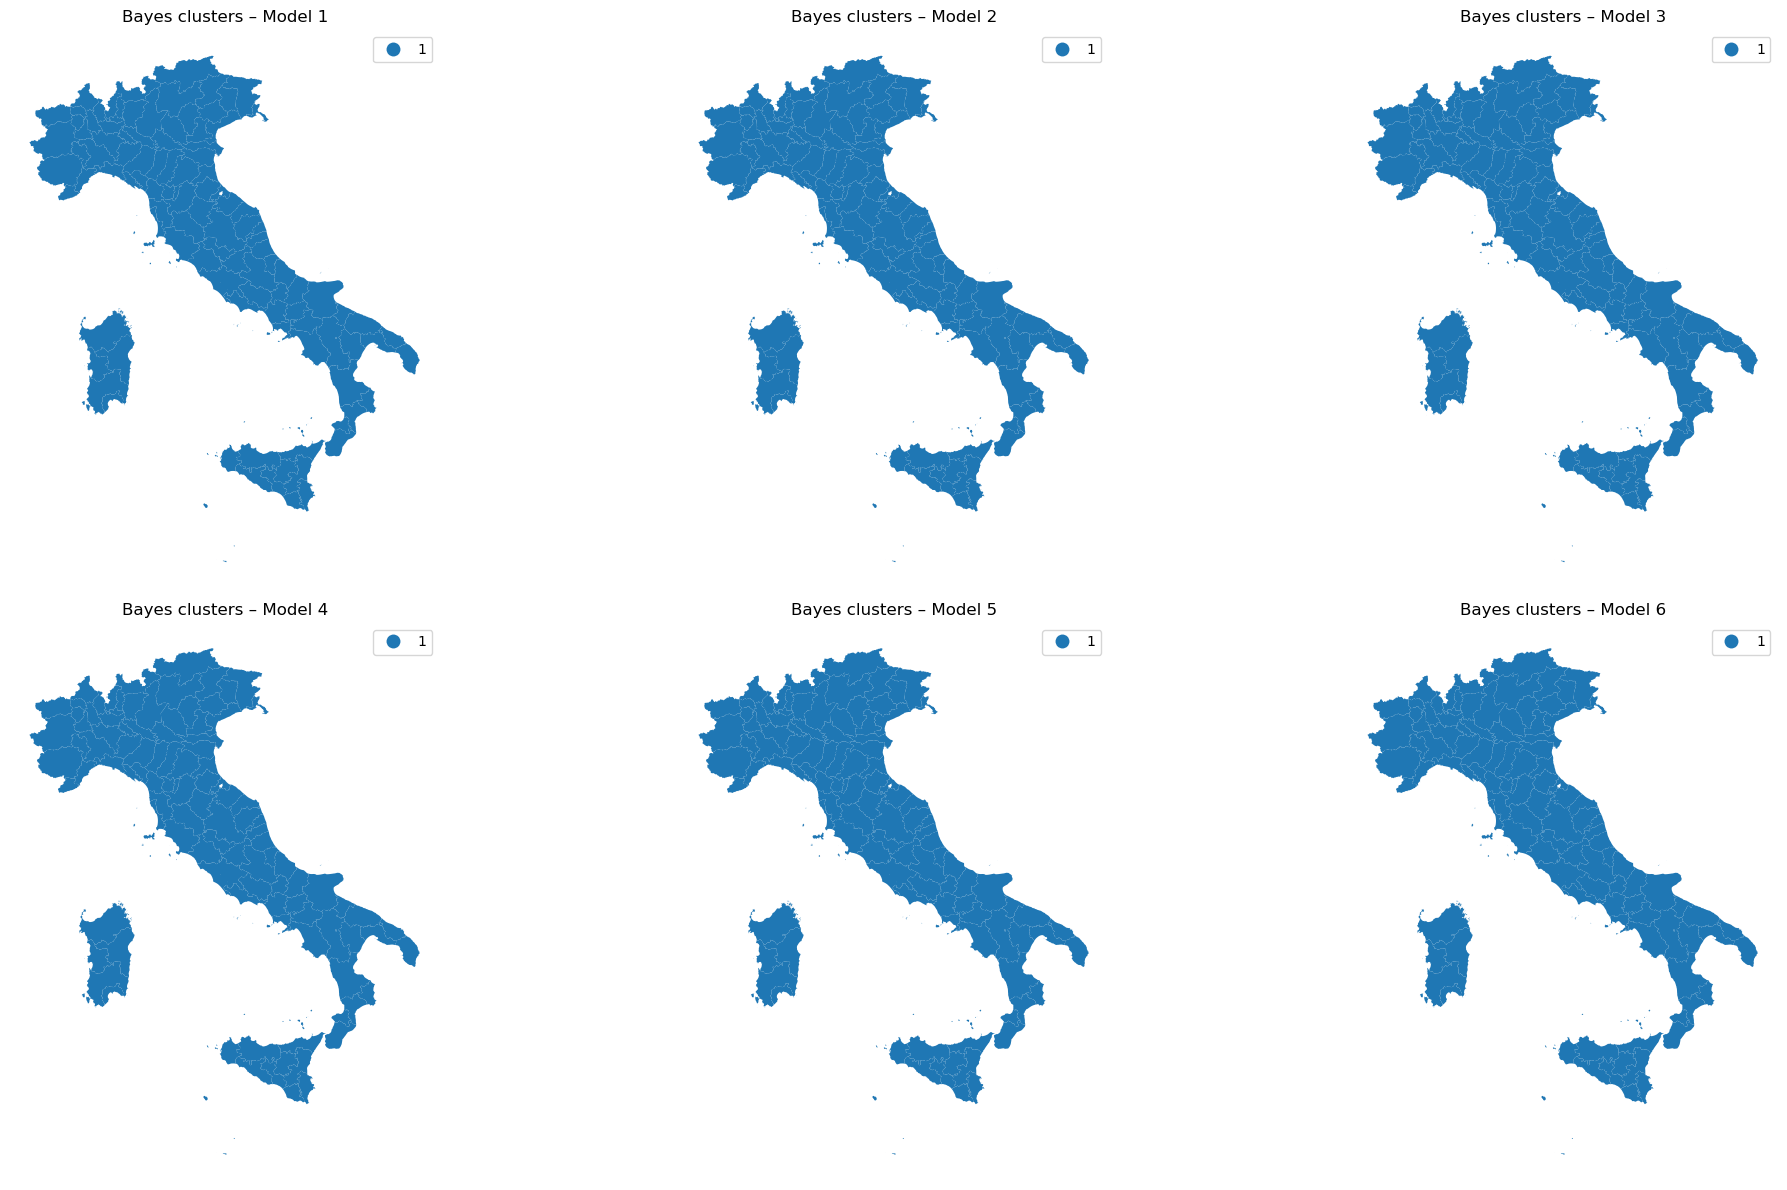

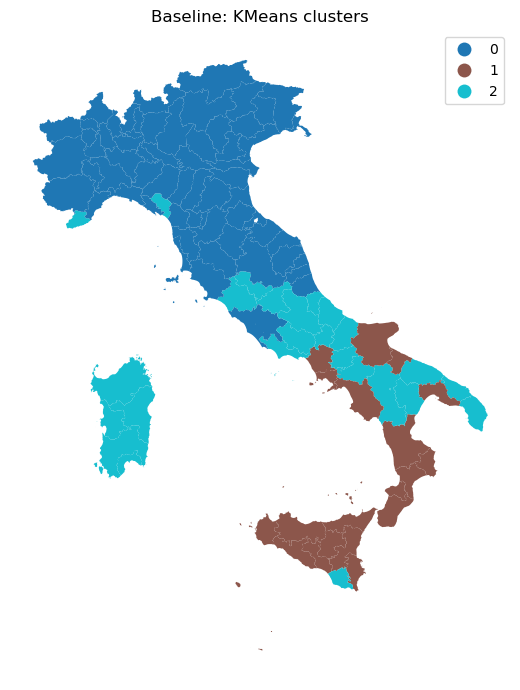

In [111]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# GeoDataFrame with one row per observation/region (must include geometry)
gdf = gpd.read_file("../data/updated_data.geojson").copy()

# Attach Bayes clusters from all 6 models
for i in range(1, 7):
    gdf[f"cluster_bayes_{i}"] = globals()[f"labels_{i}"]

# Optional baseline: k-means on the response (using model 1 y_star)
kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_star_1.reshape(-1, 1))
gdf["cluster_kmeans"] = kmeans.labels_

# 2x3 grid of the 6 Bayesian clusterings
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.ravel()
for i in range(1, 7):
    ax = axes[i-1]
    gdf.plot(column=f"cluster_bayes_{i}", categorical=True, legend=True, ax=ax)
    ax.set_title(f"Bayes clusters – Model {i}")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Baseline map (k-means)
fig, ax = plt.subplots(1, 1, figsize=(9, 7))
gdf.plot(column="cluster_kmeans", categorical=True, legend=True, ax=ax)
ax.set_title("Baseline: KMeans clusters")
ax.set_axis_off()
plt.tight_layout()
plt.show()